# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

The registry holds two trials, both bandwidth-free 2-D losses at `sigma_weight` ~0.41-0.42:
**trial_01** (`w1_2d`, sw 0.409) -> **0.0895**; **trial_02** (`energy_2d`, sw 0.423) -> **0.0996**. Both are
worse than the frozen KDE reference **0.080328**. trial_01's error was mu-heavy at low count (1nW
Trans05 collapse, 1nW Trans20 mu +66 %); trial_02 was worse still, with a systematic low-count gamma
undershoot (1nW Trans05 gamma -68 %). In both, high-T cells had mu low by ~27-46 % while gamma was
near truth. No divergences anywhere; the phase is still `uniform` (2/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.2368105065960997}
 2 |      - | {"loss_family": "kde", "sigma_weight": 0.8012744652063969}
 3 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.09412864224039919}
 4 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.4331269402364738}
 5 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.15973891463707857}
 6 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.7345771514092145}
 7 |      - | {"loss_family": "kde", "sigma_weight": 0.39122819049566204}
 8 |      - | {"loss_family": "kde", "sigma_weight": 0.5167401826213637}
 9 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.5867985714381407}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.7378377872921602}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Two families are on the board (`w1_2d` 0.0895, `energy_2d` 0.0996), both at sw ~0.41-0.42 and both worse
than the KDE control (0.0803); `mmd_2d`, `w1_fwhm`, `cvm_fwhm` and the `kde` control have no trial yet.
Still in the `uniform` phase (2/5), so continue building coverage while holding `sigma_weight` roughly
fixed so the losses are compared only by form.

Scanning the table: candidates 2, 7, 8 are `kde` (the control - it would just re-anchor 0.0803, useful
later as an independent check but not yet); 1 is `w1_fwhm` and 3 is `cvm_fwhm` (FWHM-only controls,
best saved until the S-D families are mapped); 6, 9, 10 are more `energy_2d` (already have a point).
Candidate 4 is `mmd_2d` at sw 0.433 - the remaining untested S-D family, and its sw matches trial_01/02
(0.409/0.423) almost exactly, so it slots straight into the running family comparison. Candidate 5 is
the other `mmd_2d`, but at a low sw 0.160.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'mmd_2d', 'sigma_weight': 0.4331269402364738}
Running  1nW Trans05 ... 

μ 9.39 -> 5.84 | γ 8.5 -> 2.88 | NLL -2.52


Running  1nW Trans20 ... 

μ 17.32 -> 34.29 | γ 8.5 -> 5.08 | NLL 0.35


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 43.71 | γ 14.1 -> 13.83 | NLL -3.36


Running 3nW Trans100 ... 

μ 175.71 -> 64.66 | γ 14.1 -> 13.35 | NLL -3.49



Total: 7.5 min


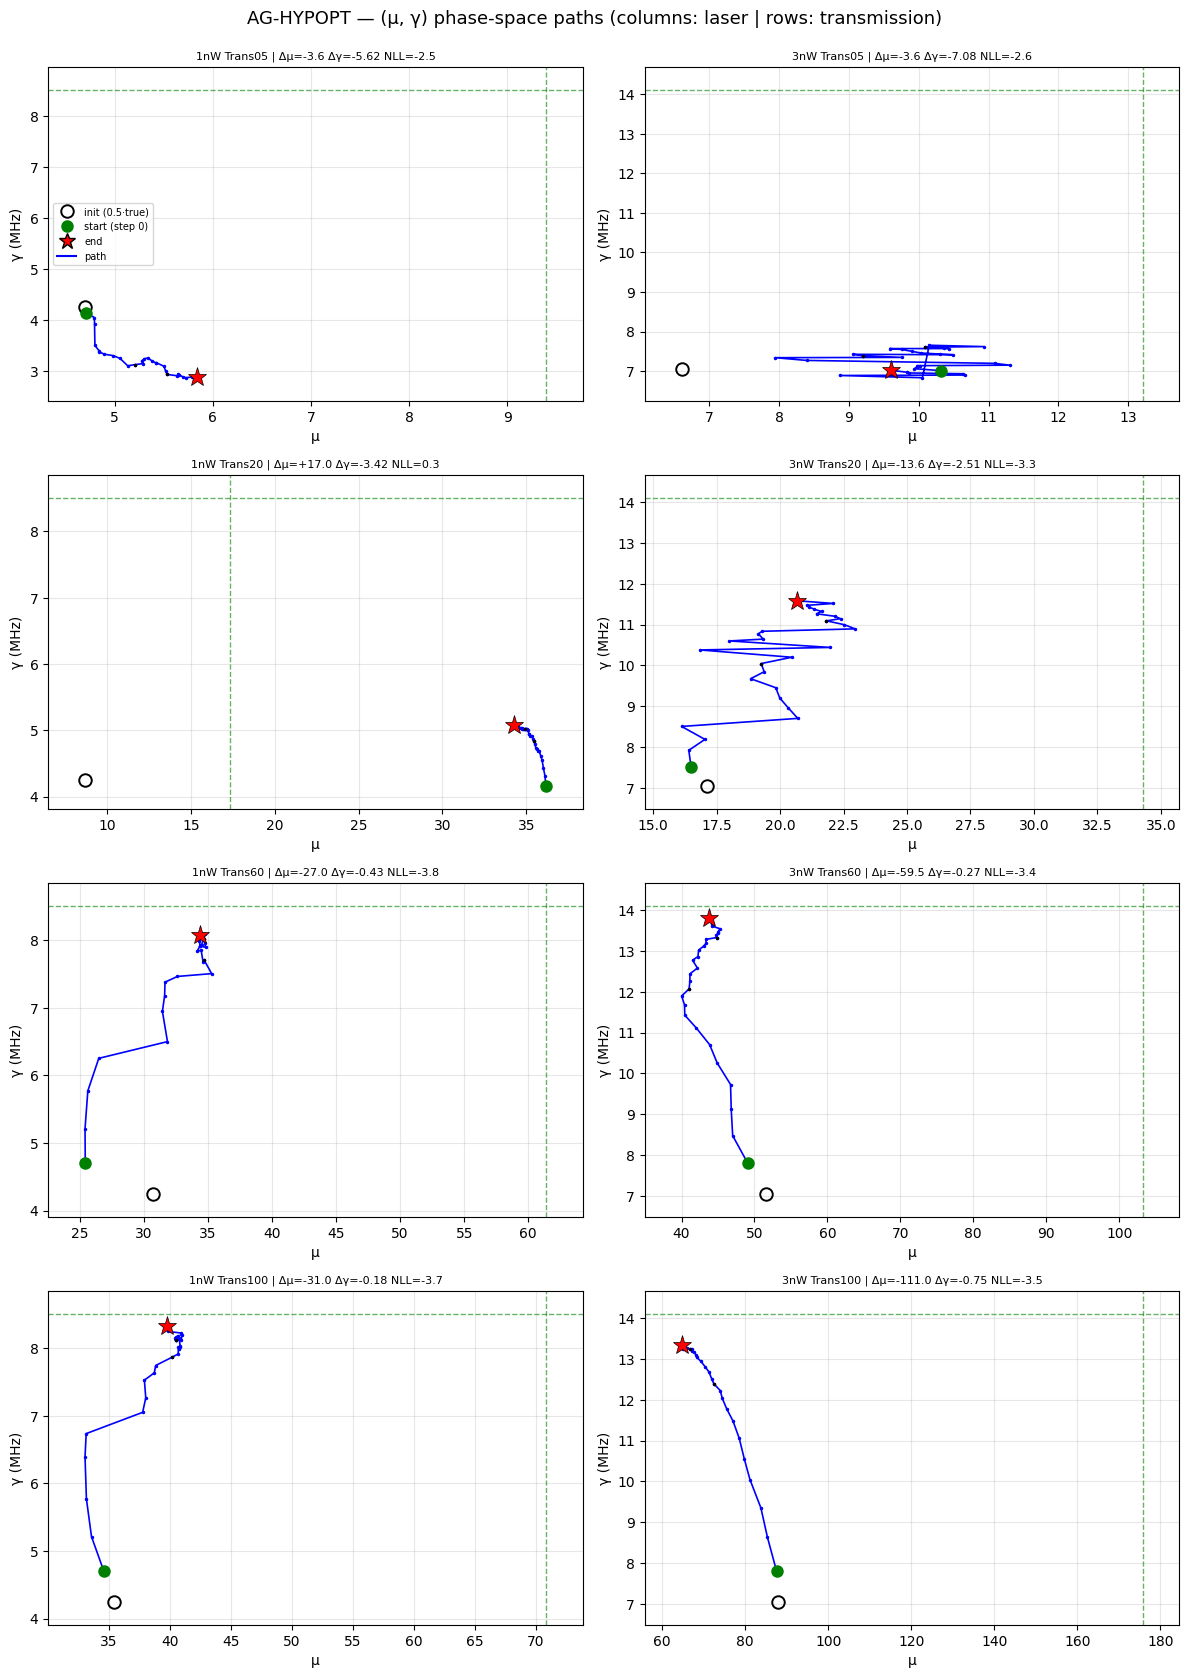

trial finished in 7.5 min
objective = 0.1833 ± 0.0613
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.84   -37.8 |     8.50    2.88   -66.2
1nW Trans20       17.32   34.29   +98.0 |     8.50    5.08   -40.2
1nW Trans60       61.37   34.42   -43.9 |     8.50    8.07    -5.0
1nW Trans100       70.82   39.79   -43.8 |     8.50    8.32    -2.1
3nW Trans05       13.20    9.60   -27.3 |    14.10    7.02   -50.2
3nW Trans20       34.28   20.66   -39.7 |    14.10   11.59   -17.8
3nW Trans60      103.20   43.71   -57.7 |    14.10   13.83    -1.9
3nW Trans100      175.71   64.66   -63.2 |    14.10   13.35    -5.4

weighted objective (T-graded, cap=1.0) = 0.1833 | diverged cells: 0
μ: RMSE 47.513 (rel 55.4%, bias -29.041) | γ: RMSE 3.546 (rel 33.3%, bias -2.533)


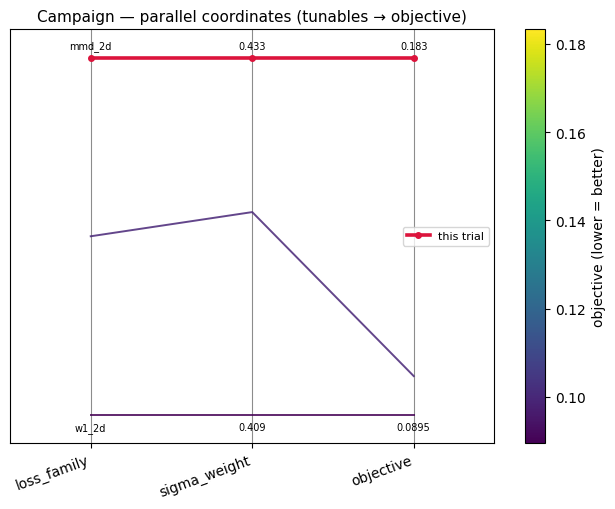

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'mmd_2d', sigma_weight: 0.4331}` (candidate 4). Trial time
7.5 min, objective **0.1833 +/- 0.0613**, **0 diverged cells**. This is by far the worst result so far:
more than double the KDE control (0.0803) and roughly double trial_01's `w1_2d` (0.0895) and trial_02's
`energy_2d` (0.0996), all at essentially the same `sigma_weight` (~0.41-0.43).

**Per-cell behaviour.** The mu channel is broken broadly, not just at low count:

- 1nW Trans05: mu -37.8 %, gamma 8.5 -> 2.88 (-66.2 %).
- 1nW Trans20: mu 17.32 -> 34.29 (**+98.0 %**, near-doubling - the largest overshoot seen).
- 1nW Trans60 / Trans100: mu -43.9 % / -43.8 %, gamma -5.0 % / -2.1 %.
- 3nW Trans05 / Trans20: mu -27.3 % / -39.7 %, gamma -50.2 % / -17.8 %.
- 3nW Trans60 / Trans100: mu -57.7 % / -63.2 % (the worst cells), gamma -1.9 % / -5.4 %.

Unlike trial_01/02, the high-T cells here also fail badly on mu (not just ~-30 % but -58 % to -63 %), so
the MMD reward does not pull mu up to the truth at all.

**Aggregates.** mu: RMSE 47.51 (rel 55.4 %), bias -29.04; gamma: RMSE 3.55 (rel 33.3 %), bias -2.53 -
both the worst of the three trials (trial_01: mu 32.3 / gamma 2.64; trial_02: mu 34.2 / gamma 3.35).

**Summary:** `mmd_2d` at sw 0.433 reaches objective 0.1833, far worse than `w1_2d` (0.0895), `energy_2d`
(0.0996) and the KDE control (0.0803), with mu low almost everywhere and no divergences.
**Key insight:** With the median-heuristic MMD kernel the mu reward is systematically too weak, leaving
mu far below truth at every transmission - the MMD form is the weakest loss tested.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'mmd_2d (sigma_weight 0.4331) reaches objective 0.1833, far worse than w1_2d (0.0895), energy_2d (0.0996) and the KDE control (0.0803), with mu low almost everywhere and no divergences.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'With the median-heuristic MMD kernel the mu reward is systematically too weak, leaving mu far below truth at every transmission; MMD is the weakest loss form tested.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
